<a href="https://colab.research.google.com/github/Sharjeeyl/Deep_Learning_Projects/blob/main/Semi_Supervised_Deep_Learning_for_Remote_Sensing_Segmentation_with_Limited_Point_Annotations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision



In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from PIL import Image
import numpy as np
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

# Use updated weights parameter
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights)



In [ ]:
class LandCoverDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_filenames = [f for f in os.listdir(data_dir) if f.endswith('_sat.jpg')]  # Select satellite images

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        mask_name = img_name.replace('_sat.jpg', '_mask.png')  # Find corresponding mask

        img_path = os.path.join(self.data_dir, img_name)
        mask_path = os.path.join(self.data_dir, mask_name)

        # Load images and masks
        image = Image.open(img_path).convert("RGB")  # Ensure image is RGB
        mask = Image.open(mask_path).convert("L")  # Convert mask to grayscale

        # Apply transformations
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        # Convert mask from [1, H, W] to [H, W]
        mask = mask.squeeze(0)

        return image, mask



In [ ]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize both images & masks
    transforms.ToTensor()
])

# Load datasets
train_dataset = LandCoverDataset(data_dir='/content/dataset/train', transform=transform)
test_dataset = LandCoverDataset(data_dir='/content/dataset/test', transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"Total training samples: {len(train_dataset)}")
print(f"Total testing samples: {len(test_dataset)}")


Total training samples: 803
Total testing samples: 172


In [ ]:
# Visual check of dataset
sample_img, sample_mask = train_dataset[0]
print(f"Image shape: {sample_img.shape}, Mask shape: {sample_mask.shape}")


Image shape: torch.Size([3, 256, 256]), Mask shape: torch.Size([256, 256])


In [ ]:
class PartialCrossEntropyLoss(nn.Module):
    def __init__(self):
        super(PartialCrossEntropyLoss, self).__init__()
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')  # Compute per-pixel loss

    def forward(self, outputs, sparse_labels, sparse_mask):
        loss = self.ce_loss(outputs, sparse_labels) * sparse_mask  # Apply sparse mask
        return loss.sum() / sparse_mask.sum()  # Normalize loss


In [ ]:
def get_segmentation_model(num_classes):
    weights = DeepLabV3_ResNet50_Weights.DEFAULT
    model = deeplabv3_resnet50(weights=weights)

    # Modify the classifier for custom classes
    model.classifier[4] = torch.nn.Conv2d(256, num_classes, kernel_size=(1, 1))
    return model


In [ ]:
def sample_sparse_labels(mask_numpy, num_samples=500):
    h, w = mask_numpy.shape
    sparse_labels = np.zeros_like(mask_numpy, dtype=np.int64)
    sparse_mask = np.zeros_like(mask_numpy, dtype=np.float32)

    # Randomly select `num_samples` pixels for sparse annotation
    for _ in range(num_samples):
        x, y = np.random.randint(0, w), np.random.randint(0, h)
        sparse_labels[y, x] = mask_numpy[y, x]  # Assign label
        sparse_mask[y, x] = 1.0  # Mark as labeled

    return sparse_labels, sparse_mask


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
num_classes = 7
model = get_segmentation_model(num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = PartialCrossEntropyLoss()

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        # Convert masks to sparse format
        masks_numpy = masks.squeeze().cpu().numpy()

        # Ensure mask is 2D by taking the first channel if it exists
        if masks_numpy.ndim == 3:
            masks_numpy = masks_numpy[0]

        # Sample sparse labels
        sparse_labels, sparse_mask = sample_sparse_labels(masks_numpy)

        # Convert back to tensors
        sparse_labels = torch.tensor(sparse_labels, dtype=torch.long, device=device)
        sparse_mask = torch.tensor(sparse_mask, dtype=torch.float32, device=device)

        # 🛠 FIX: Expand sparse_labels to match model output batch size
        sparse_labels = sparse_labels.unsqueeze(0).expand(images.shape[0], -1, -1)

        optimizer.zero_grad()
        outputs = model(images)['out']

        loss = criterion(outputs, sparse_labels, sparse_mask)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")

print("Outputs shape:", outputs.shape)  # Should be (batch_size, num_classes, H, W)
print("Sparse labels shape:", sparse_labels.shape)  # Should be (batch_size, H, W)




Epoch [1/10], Loss: 10.8986
Epoch [2/10], Loss: 5.1149
Epoch [3/10], Loss: 3.7844
Epoch [4/10], Loss: 2.4359
Epoch [5/10], Loss: 3.1791
Epoch [6/10], Loss: 3.6785
Epoch [7/10], Loss: 2.6106
Epoch [8/10], Loss: 2.7667
Epoch [9/10], Loss: 1.9271
Epoch [10/10], Loss: 1.8179
Outputs shape: torch.Size([3, 7, 256, 256])
Sparse labels shape: torch.Size([3, 256, 256])


In [ ]:
# Save the trained model
torch.save(model.state_dict(), "segmentation_model.pth")
print("Model saved successfully!")

# Load the model for inference
model.load_state_dict(torch.load("segmentation_model.pth"))
model.eval()


Model saved successfully!


<ipython-input-14-c565cafb5701>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("segmentation_model.pth"))


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [ ]:
import os
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

class SegmentationDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        # Get all image filenames (only JPG files)
        self.image_filenames = sorted([
            f for f in os.listdir(root_dir) if f.endswith("_sat.jpg")
        ])

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        # Get image path
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.root_dir, img_name)

        # Get corresponding mask path (replace '_sat.jpg' with '_mask.png')
        mask_name = img_name.replace("_sat.jpg", "_mask.png")
        mask_path = os.path.join(self.root_dir, mask_name)

        # Load image & mask
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # Convert mask to grayscale

        # Apply transforms (if any)
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

# Load dataset
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert to PyTorch tensor
])
test_dataset = SegmentationDataset("/content/dataset/test", transform=transform)




In [ ]:
import os

file_path = "/content/dataset/test/100877_mask.png"

if os.path.exists(file_path):
    print(" File exists:", file_path)
else:
    print(" File NOT found:", file_path)


❌ File NOT found: /content/dataset/test/100877_mask.png


In [ ]:
import os

test_dir = "/content/dataset/test"
files = os.listdir(test_dir)
print(" Available files:", files[:10])  # Print first 10 files


🔍 Available files: ['220639_sat.jpg', '19849_sat.jpg', '288127_sat.jpg', '452523_sat.jpg', '215115_sat.jpg', '119896_sat.jpg', '468917_sat.jpg', '32207_sat.jpg', '430722_sat.jpg', '103742_sat.jpg']


In [ ]:
class SegmentationDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        # Get all image filenames
        self.image_filenames = sorted([
            f for f in os.listdir(root_dir) if f.endswith("_sat.jpg")
        ])

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.root_dir, img_name)

        # Construct mask path dynamically
        mask_name = img_name.replace("_sat.jpg", "_mask.png")
        mask_path = os.path.join(self.root_dir, mask_name)

        # Check if mask exists
        if not os.path.exists(mask_path):
            print(f" Mask file missing: {mask_path}")
            return None  # Skip missing files

        # Load image & mask
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Apply transforms
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask


In [ ]:
import os
print(os.listdir("/content/dataset/test")[:10])  # Check contents of test folder


['220639_sat.jpg', '19849_sat.jpg', '288127_sat.jpg', '452523_sat.jpg', '215115_sat.jpg', '119896_sat.jpg', '468917_sat.jpg', '32207_sat.jpg', '430722_sat.jpg', '103742_sat.jpg']


In [ ]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import os

class SatelliteDataset(Dataset):
    def __init__(self, image_dir, mask_dir=None, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir  # Mask dir is optional for test data
        self.transform = transform

        self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith("_sat.jpg")])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.mask_dir:
            mask_filename = self.image_files[idx].replace("_sat.jpg", "_mask.png")
            mask_path = os.path.join(self.mask_dir, mask_filename)
            mask = Image.open(mask_path).convert("L")

            if self.transform:
                mask = self.transform(mask)

            return image, mask  # Train dataset returns both image and mask
        else:
            return image  # Test dataset returns only image



In [ ]:
# Define image transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#  Load training dataset (with masks)
train_image_dir = "/content/dataset/train"
train_mask_dir = "/content/dataset/train"  # Because masks are in the train folder
train_dataset = SatelliteDataset(train_image_dir, train_mask_dir, transform=transform)

# Load test dataset (without masks)
test_image_dir = "/content/dataset/test"
test_dataset = SatelliteDataset(test_image_dir, transform=transform)  # No mask_dir for test


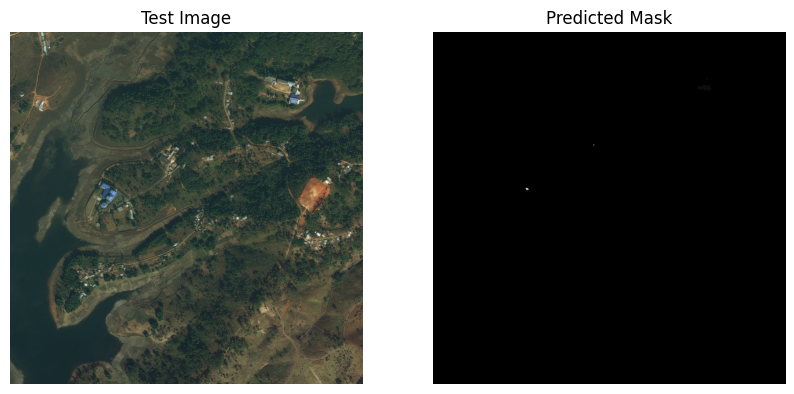

In [ ]:
import matplotlib.pyplot as plt
import torch

def visualize_prediction(model, dataset, idx, device="cuda" if torch.cuda.is_available() else "cpu"):
    model.to(device)  # Move model to the correct device
    image = dataset[idx].to(device)  # Move image to the same device as model
    image = image.unsqueeze(0)  # Add batch dimension

    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation
        output = model(image)['out']

    predicted_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()  # Move mask to CPU for visualization

    # Convert image tensor to NumPy array for visualization
    image_np = image.squeeze().permute(1, 2, 0).cpu().numpy()
    image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())  # Normalize for display

    # Plot original image and predicted mask
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image_np)
    axes[0].set_title("Test Image")
    axes[0].axis("off")

    axes[1].imshow(predicted_mask, cmap="gray")
    axes[1].set_title("Predicted Mask")
    axes[1].axis("off")

    plt.show()

#Test visualization on a sample from the test dataset
visualize_prediction(model, test_dataset, idx=0)


In [ ]:
torch.save(model.state_dict(), "segmentation_model.pth")
